# Retail Sales Analysis Project

## Business Problem
The objective of this project is to analyse retail sales data to identify trends, customer behaviour, regional performance, and profitability drivers. The analysis aims to support business decision-making through data cleaning, exploratory analysis, and visual reporting.

1. Business Problem
2. Import Libraries
3. Load Dataset
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis
7. Business Insights
8. Conclusion
9. Export Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv(
    "Sample-Superstore.csv",
    encoding="latin1"
)

In [11]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
df.shape

(9994, 21)

In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [15]:
df.duplicated().sum()

0

In [20]:
##Not needed as there are no duplicates df = df.drop_duplicates()

In [23]:
df['Order Month'] = df['Order Date'].dt.month_name()

In [27]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,order_month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,October


## Step 1: Clean column names

In [25]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'order_month'],
      dtype='object')

## Step 2: Convert date columns

In [26]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

df[["order_date", "ship_date"]].head()

,order_date,ship_date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


## Step 3: Create useful business columns

In [28]:
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month_name()
df["order_month_number"] = df["order_date"].dt.month
df["order_quarter"] = df["order_date"].dt.quarter
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

## Step 4: Create profit margin

In [29]:
df["profit_margin"] = (df["profit"] / df["sales"]) * 100
df["profit_margin"] = df["profit_margin"].round(2)

df[["sales", "profit", "profit_margin"]].head()

,sales,profit,profit_margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


## Step 5: Check for weird values

In [30]:
df[["sales", "quantity", "discount", "profit", "shipping_days"]].describe()

,sales,quantity,discount,profit,shipping_days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,3.958175
std,623.245101,2.225110,0.206452,234.260108,1.747567
min,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,17.280000,2.000000,0.000000,1.728750,3.000000
50%,54.490000,3.000000,0.200000,8.666500,4.000000
75%,209.940000,5.000000,0.200000,29.364000,5.000000
max,22638.480000,14.000000,0.800000,8399.976000,7.000000


In [31]:
df[df["sales"] <= 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_month,order_year,order_month_number,order_quarter,shipping_days,profit_margin


In [32]:
df[df["quantity"] <= 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_month,order_year,order_month_number,order_quarter,shipping_days,profit_margin


In [33]:
df[df["discount"] < 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_month,order_year,order_month_number,order_quarter,shipping_days,profit_margin


In [34]:
df[df["discount"] > 1]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_month,order_year,order_month_number,order_quarter,shipping_days,profit_margin


In [35]:
df[df["shipping_days"] < 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_month,order_year,order_month_number,order_quarter,shipping_days,profit_margin


## Step 6: Check loss-making orders

In [36]:
loss_orders = df[df["profit"] < 0]

loss_orders.shape

(1871, 27)

In [37]:
loss_orders[["category", "sub_category", "sales", "discount", "profit"]].head()

,category,sub_category,sales,discount,profit
3,Furniture,Tables,957.5775,0.45,-383.0310
14,Office Supplies,Appliances,68.8100,0.80,-123.8580
15,Office Supplies,Binders,2.5440,0.80,-3.8160
23,Furniture,Chairs,71.3720,0.30,-1.0196
27,Furniture,Bookcases,3083.4300,0.50,-1665.0522


## Step 7: Quick business insights

In [38]:
total_sales = df["sales"].sum()
total_sales

2297200.8603000003

In [39]:
total_profit = df["profit"].sum()
total_profit

286397.0217

In [40]:
overall_profit_margin = (total_profit / total_sales) * 100
overall_profit_margin

12.467217240315604

In [41]:
df.groupby("category")["sales"].sum().sort_values(ascending=False)

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

In [42]:
df.groupby("category")["profit"].sum().sort_values(ascending=False)

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

In [43]:
df.groupby("state")["sales"].sum().sort_values(ascending=False).head(10)

state
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: sales, dtype: float64

### Monthly sales trend

In [44]:
monthly_sales = (
    df.groupby(["order_year", "order_month_number", "order_month"])["sales"]
    .sum()
    .reset_index()
    .sort_values(["order_year", "order_month_number"])
)

monthly_sales.head()

,order_year,order_month_number,order_month,sales
0,2014,1,January,14236.895
1,2014,2,February,4519.892
2,2014,3,March,55691.009
3,2014,4,April,28295.345
4,2014,5,May,23648.287


In [45]:
df.to_csv("superstore_cleaned.csv", index=False)

# EDA + insight generation.

### Step 1: Create a simple KPI summary

In [46]:
kpi_summary = {
    "Total Sales": round(df["sales"].sum(), 2),
    "Total Profit": round(df["profit"].sum(), 2),
    "Total Orders": df["order_id"].nunique(),
    "Total Customers": df["customer_id"].nunique(),
    "Average Order Value": round(df["sales"].sum() / df["order_id"].nunique(), 2),
    "Overall Profit Margin %": round((df["profit"].sum() / df["sales"].sum()) * 100, 2)
}

kpi_summary

{'Total Sales': 2297200.86,
 'Total Profit': 286397.02,
 'Total Orders': 5009,
 'Total Customers': 793,
 'Average Order Value': 458.61,
 'Overall Profit Margin %': 12.47}

### Step 2: Find sales and profit by category

In [47]:
category_summary = (
    df.groupby("category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

category_summary["profit_margin_%"] = (
    category_summary["total_profit"] / category_summary["total_sales"] * 100
).round(2)

category_summary.sort_values("total_sales", ascending=False)

,category,total_sales,total_profit,total_quantity,avg_discount,profit_margin_%
2,Technology,836154.0330,145454.9481,6939,0.132323,17.40
0,Furniture,741999.7953,18451.2728,8028,0.173923,2.49
1,Office Supplies,719047.0320,122490.8008,22906,0.157285,17.04


### Step 3: Find weak/loss-making areas

In [48]:
sub_category_summary = (
    df.groupby("sub_category")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        avg_discount=("discount", "mean")
    )
    .reset_index()
)

sub_category_summary["profit_margin_%"] = (
    sub_category_summary["total_profit"] / sub_category_summary["total_sales"] * 100
).round(2)

sub_category_summary.sort_values("total_profit").head(10)

,sub_category,total_sales,total_profit,total_quantity,avg_discount,profit_margin_%
16,Tables,206965.5320,-17725.4811,1241,0.261285,-8.56
4,Bookcases,114879.9963,-3472.5560,868,0.211140,-3.02
15,Supplies,46673.5380,-1189.0995,647,0.076842,-2.55
8,Fasteners,3024.2800,949.5182,914,0.082028,31.40
11,Machines,189238.6310,3384.7569,440,0.306087,1.79
10,Labels,12486.3120,5546.2540,1400,0.068681,44.42
2,Art,27118.7920,6527.7870,3000,0.074874,24.07
7,Envelopes,16476.4020,6964.1767,906,0.080315,42.27
9,Furnishings,91705.1640,13059.1436,3563,0.138349,14.24
1,Appliances,107532.1610,18138.0054,1729,0.166524,16.87


### Step 4: Monthly sales trend

In [49]:
monthly_summary = (
    df.groupby(["order_year", "order_month_number", "order_month"])
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values(["order_year", "order_month_number"])
)

monthly_summary.head()

,order_year,order_month_number,order_month,total_sales,total_profit,total_orders
0,2014,1,January,14236.895,2450.1907,32
1,2014,2,February,4519.892,862.3084,28
2,2014,3,March,55691.009,498.7299,71
3,2014,4,April,28295.345,3488.8352,66
4,2014,5,May,23648.287,2738.7096,69


### Step 5: Region performance

In [50]:
region_summary = (
    df.groupby("region")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

region_summary["profit_margin_%"] = (
    region_summary["total_profit"] / region_summary["total_sales"] * 100
).round(2)

region_summary.sort_values("total_sales", ascending=False)

,region,total_sales,total_profit,total_orders,profit_margin_%
3,West,725457.8245,108418.4489,1611,14.94
1,East,678781.2400,91522.7800,1401,13.48
0,Central,501239.8908,39706.3625,1175,7.92
2,South,391721.9050,46749.4303,822,11.93


### Step 6: Customer segment performance

In [51]:
segment_summary = (
    df.groupby("segment")
    .agg(
        total_sales=("sales", "sum"),
        total_profit=("profit", "sum"),
        total_orders=("order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

segment_summary["profit_margin_%"] = (
    segment_summary["total_profit"] / segment_summary["total_sales"] * 100
).round(2)

segment_summary.sort_values("total_sales", ascending=False)

,segment,total_sales,total_profit,total_orders,customers,profit_margin_%
0,Consumer,1.161401e+06,134119.2092,2586,409,11.55
1,Corporate,7.061464e+05,91979.1340,1514,236,13.03
2,Home Office,4.296531e+05,60298.6785,909,148,14.03


### Step 7: Export these summary tables too

In [52]:
category_summary.to_csv("category_summary.csv", index=False)
sub_category_summary.to_csv("sub_category_summary.csv", index=False)
monthly_summary.to_csv("monthly_summary.csv", index=False)
region_summary.to_csv("region_summary.csv", index=False)
segment_summary.to_csv("segment_summary.csv", index=False)

# Charts

In [53]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

### Chart 1 — Monthly Sales Trend



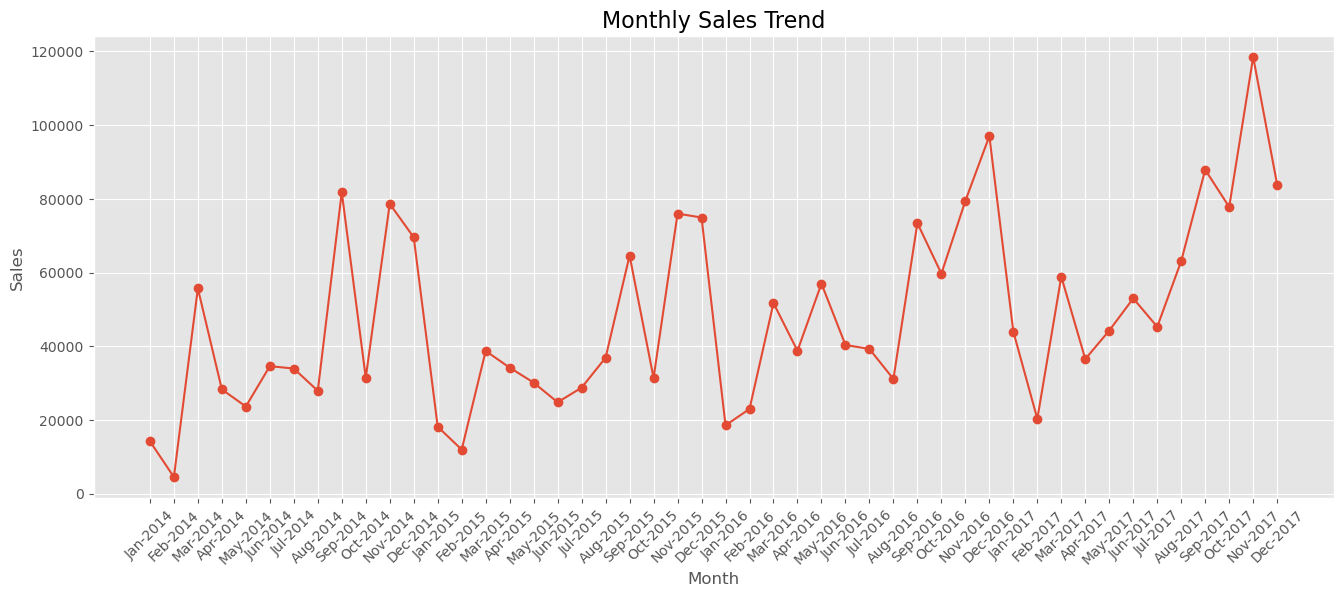

In [61]:
monthly_sales_chart = (
    df.groupby(["order_year", "order_month_number", "order_month"])["sales"]
    .sum()
    .reset_index()
    .sort_values(["order_year", "order_month_number"])
)

monthly_sales_chart["month_label"] = (
    monthly_sales_chart["order_month"].str[:3]
    + "-"
    + monthly_sales_chart["order_year"].astype(str)
)

plt.figure(figsize=(16,6))

plt.plot(
    monthly_sales_chart["month_label"],
    monthly_sales_chart["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Chart 2 — Sales by Category

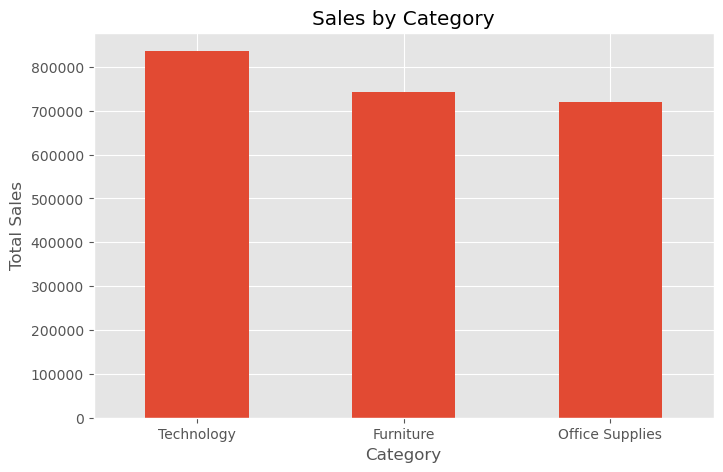

In [55]:
category_sales = (
    df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

### Chart 3 — Profit by Category

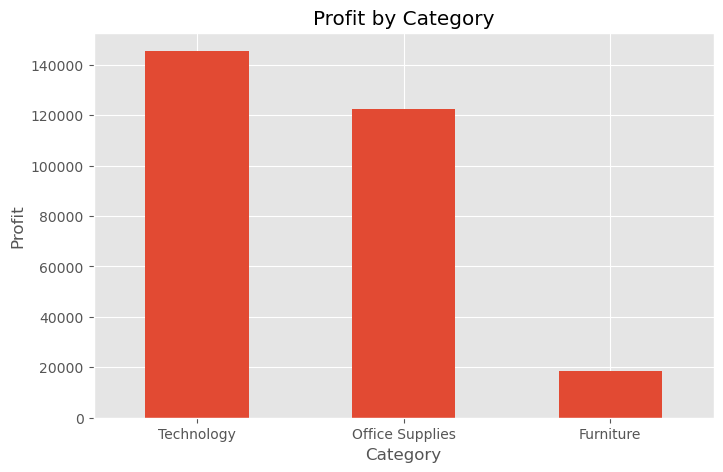

In [56]:
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=0)

plt.show()

### Chart 4 — Top 10 States by Sales

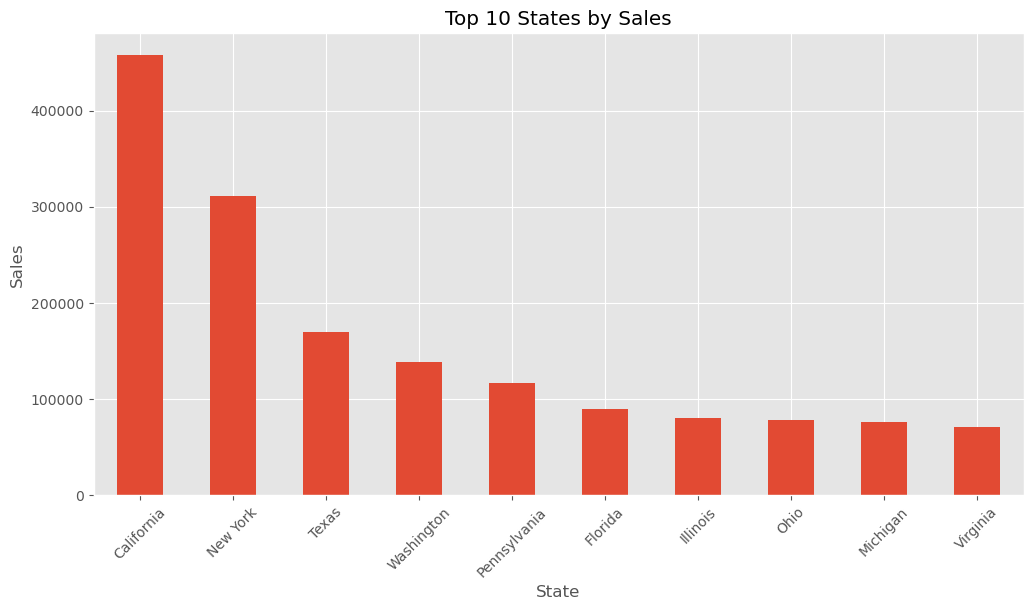

In [57]:
top_states = (
    df.groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Chart 5 — Customer Segment Distribution

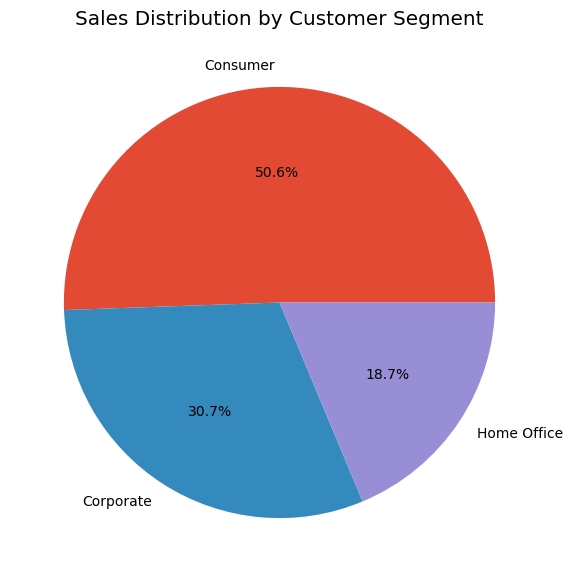

In [58]:
segment_sales = (
    df.groupby("segment")["sales"]
    .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Customer Segment")

plt.show()

### Chart 6 — Profit vs Discount

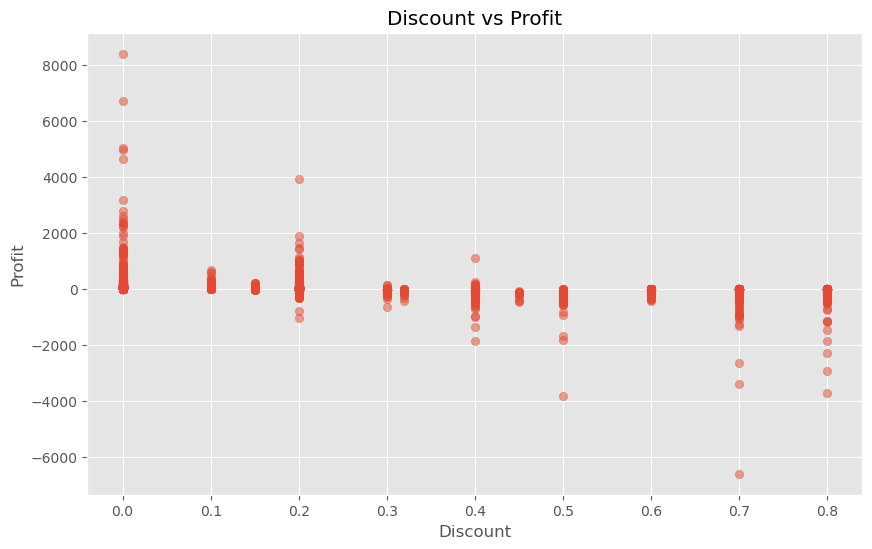

In [59]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["discount"],
    df["profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Chart 7 — Shipping Days Distribution

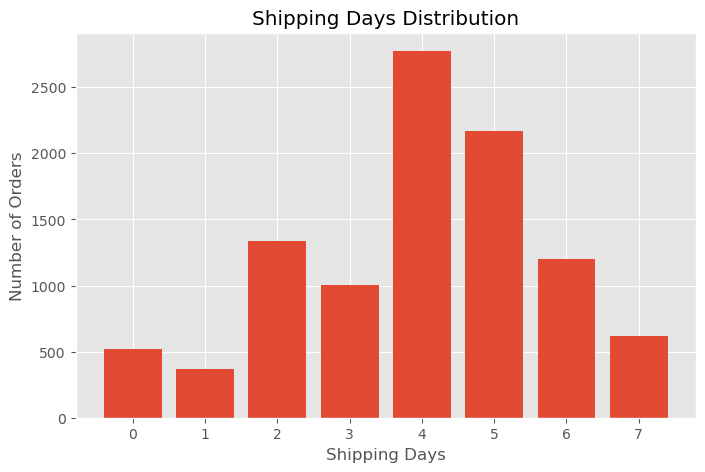

In [62]:
plt.figure(figsize=(8,5))

plt.hist(
    df["shipping_days"],
    bins=range(0,9),
    align="left",
    rwidth=0.8
)

plt.title("Shipping Days Distribution")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.xticks(range(0,8))

plt.show()